<a href="https://colab.research.google.com/github/tompopo777/carbon-emission-inventory-system/blob/main/Harry_Potter_LDA_NMF_BERTopic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np

from google.colab import drive
drive.mount('/content/drive')
file_path = '/content/drive/My Drive/Colab Notebooks/Social Media TxtMining/dataset/Harry Potter Movies Dataset_merged_data.csv'

df = pd.read_csv(file_path, low_memory=False)
df = df.iloc[:, 1:]
df

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,movie,chapter,character,dialog,gender,releaseYear
0,Harry Potter and the Half-Blood Prince,Snape's Visitors,bellatrix lestrange,Narcissa!,female,2009
1,Harry Potter and the Half-Blood Prince,Snape's Visitors,bellatrix lestrange,Cissy! You mustn't do this. He can't be trusted.,female,2009
2,Harry Potter and the Half-Blood Prince,Snape's Visitors,narcissa malfoy,The Dark Lord trusts him.,female,2009
3,Harry Potter and the Half-Blood Prince,Snape's Visitors,bellatrix lestrange,The Dark Lord is mistaken.,female,2009
4,Harry Potter and the Half-Blood Prince,Snape's Visitors,bellatrix lestrange,Or so I believe.,female,2009
...,...,...,...,...,...,...
7440,Harry Potter and the Deathly Hallows Part 2,Nineteen Years Later,harry potter,Then Slytherin House will have gained a wonder...,male,2011
7441,Harry Potter and the Deathly Hallows Part 2,Nineteen Years Later,albus potter,Really?,male,2011
7442,Harry Potter and the Deathly Hallows Part 2,Nineteen Years Later,harry potter,Really.,male,2011
7443,Harry Potter and the Deathly Hallows Part 2,Nineteen Years Later,harry potter,Ready?,male,2011


In [ ]:
import pandas as pd
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import TreebankWordTokenizer

# Download required NLTK data (no punkt to avoid issues)
nltk.download('stopwords', quiet=True)

# Use TreebankWordTokenizer instead of word_tokenize
tokenizer = TreebankWordTokenizer()

# Define stop words
stop_words = set(stopwords.words('english'))

raw_text_column = 'dialog'  # update if needed

# Step 1: Clean the text
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', '', text)
    return text

df['clean_text'] = df[raw_text_column].fillna('').apply(clean_text)

# Step 2: Tokenize and remove stopwords
def tokenize(text):
    tokens = tokenizer.tokenize(text)
    return [word for word in tokens if word not in stop_words and len(word) > 2]

df['tokens'] = df['clean_text'].apply(tokenize)

df
# df.to_csv("/content/drive/My Drive/Colab Notebooks/Social Media TxtMining/dataset/Harry Potter Movies Dataset_clean_data.csv", index=False)

,movie,chapter,character,dialog,gender,releaseYear,clean_text,tokens
0,Harry Potter and the Half-Blood Prince,Snape's Visitors,bellatrix lestrange,Narcissa!,female,2009,narcissa,[narcissa]
1,Harry Potter and the Half-Blood Prince,Snape's Visitors,bellatrix lestrange,Cissy! You mustn't do this. He can't be trusted.,female,2009,cissy you mustnt do this he cant be trusted,"[cissy, mustnt, cant, trusted]"
2,Harry Potter and the Half-Blood Prince,Snape's Visitors,narcissa malfoy,The Dark Lord trusts him.,female,2009,the dark lord trusts him,"[dark, lord, trusts]"
3,Harry Potter and the Half-Blood Prince,Snape's Visitors,bellatrix lestrange,The Dark Lord is mistaken.,female,2009,the dark lord is mistaken,"[dark, lord, mistaken]"
4,Harry Potter and the Half-Blood Prince,Snape's Visitors,bellatrix lestrange,Or so I believe.,female,2009,or so i believe,[believe]
...,...,...,...,...,...,...,...,...
7440,Harry Potter and the Deathly Hallows Part 2,Nineteen Years Later,harry potter,Then Slytherin House will have gained a wonder...,male,2011,then slytherin house will have gained a wonder...,"[slytherin, house, gained, wonderful, wizard, ..."
7441,Harry Potter and the Deathly Hallows Part 2,Nineteen Years Later,albus potter,Really?,male,2011,really,[really]
7442,Harry Potter and the Deathly Hallows Part 2,Nineteen Years Later,harry potter,Really.,male,2011,really,[really]
7443,Harry Potter and the Deathly Hallows Part 2,Nineteen Years Later,harry potter,Ready?,male,2011,ready,[ready]


# **LDA**

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

# Step 3.1: Vectorize the cleaned text
vectorizer = CountVectorizer(
    stop_words='english',     # extra filtering
    max_df=0.95,              # ignore words in >95% of scenes
    min_df=5                  # ignore rare words (<5 scenes)
)

X = vectorizer.fit_transform(df['clean_text'])  # document-term matrix

# Step 3.2: Train the LDA model
n_topics = 5  # adjust based on BERTopic or your evaluation plan

lda_model = LatentDirichletAllocation(
    n_components=n_topics,
    max_iter=10,
    learning_method='batch',
    random_state=42
)

lda_model.fit(X)

LatentDirichletAllocation(n_components=5, random_state=42)

In [ ]:
lda_topics = []
feature_names = vectorizer.get_feature_names_out()

for topic_idx, topic_weights in enumerate(lda_model.components_):
    top_indices = topic_weights.argsort()[:-11:-1]
    top_words = [feature_names[i] for i in top_indices]
    print(f"Topic {topic_idx}:\n{', '.join(top_words)}\n")
    lda_topics.append(top_words)

Topic 0:
come, dumbledore, hagrid, thats, didnt, thought, let, voldemort, told, kill

Topic 1:
dont, did, know, like, just, harry, say, want, sorry, time

Topic 2:
harry, think, sir, good, dont, potter, ron, dobby, just, youre

Topic 3:
right, got, hermione, whats, yeah, theres, mr, doing, potter, stop

Topic 4:
oh, yes, im, professor, hes, thats, snape, need, going, ask



In [ ]:
# Get the topic distribution for each scene (document)
topic_distributions = lda_model.transform(X)  # shape: (num_scenes, num_topics)

# Assign each scene the topic with the highest probability
df['lda_topic'] = topic_distributions.argmax(axis=1)
df

,movie,chapter,character,dialog,gender,releaseYear,clean_text,tokens,lda_topic
0,Harry Potter and the Half-Blood Prince,Snape's Visitors,bellatrix lestrange,Narcissa!,female,2009,narcissa,[narcissa],0
1,Harry Potter and the Half-Blood Prince,Snape's Visitors,bellatrix lestrange,Cissy! You mustn't do this. He can't be trusted.,female,2009,cissy you mustnt do this he cant be trusted,"[cissy, mustnt, cant, trusted]",4
2,Harry Potter and the Half-Blood Prince,Snape's Visitors,narcissa malfoy,The Dark Lord trusts him.,female,2009,the dark lord trusts him,"[dark, lord, trusts]",0
3,Harry Potter and the Half-Blood Prince,Snape's Visitors,bellatrix lestrange,The Dark Lord is mistaken.,female,2009,the dark lord is mistaken,"[dark, lord, mistaken]",0
4,Harry Potter and the Half-Blood Prince,Snape's Visitors,bellatrix lestrange,Or so I believe.,female,2009,or so i believe,[believe],1
...,...,...,...,...,...,...,...,...,...
7440,Harry Potter and the Deathly Hallows Part 2,Nineteen Years Later,harry potter,Then Slytherin House will have gained a wonder...,male,2011,then slytherin house will have gained a wonder...,"[slytherin, house, gained, wonderful, wizard, ...",3
7441,Harry Potter and the Deathly Hallows Part 2,Nineteen Years Later,albus potter,Really?,male,2011,really,[really],2
7442,Harry Potter and the Deathly Hallows Part 2,Nineteen Years Later,harry potter,Really.,male,2011,really,[really],2
7443,Harry Potter and the Deathly Hallows Part 2,Nineteen Years Later,harry potter,Ready?,male,2011,ready,[ready],1


In [ ]:
topic_counts = df.groupby(['movie', 'lda_topic']).size().reset_index(name='count')
print(topic_counts)

                                          movie  lda_topic  count
0       Harry Potter and the Chamber of Secrets          0    246
1       Harry Potter and the Chamber of Secrets          1    211
2       Harry Potter and the Chamber of Secrets          2    229
3       Harry Potter and the Chamber of Secrets          3    157
4       Harry Potter and the Chamber of Secrets          4    144
5   Harry Potter and the Deathly Hallows Part 1          0    281
6   Harry Potter and the Deathly Hallows Part 1          1    192
7   Harry Potter and the Deathly Hallows Part 1          2    234
8   Harry Potter and the Deathly Hallows Part 1          3    177
9   Harry Potter and the Deathly Hallows Part 1          4    128
10  Harry Potter and the Deathly Hallows Part 2          0    200
11  Harry Potter and the Deathly Hallows Part 2          1    161
12  Harry Potter and the Deathly Hallows Part 2          2    136
13  Harry Potter and the Deathly Hallows Part 2          3     93
14  Harry 

In [ ]:
dominant_topics = topic_counts.loc[topic_counts.groupby('movie')['count'].idxmax()]
print(dominant_topics)

                                          movie  lda_topic  count
0       Harry Potter and the Chamber of Secrets          0    246
5   Harry Potter and the Deathly Hallows Part 1          0    281
10  Harry Potter and the Deathly Hallows Part 2          0    200
15          Harry Potter and the Goblet of Fire          0    205
20       Harry Potter and the Half-Blood Prince          0    275
25    Harry Potter and the Order of the Phoenix          0    325
30     Harry Potter and the Philosopher's Stone          0    216
35     Harry Potter and the Prisoner of Azkaban          0    206


## **NMF**

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Step 2: Vectorize using TF-IDF
tfidf_vectorizer = TfidfVectorizer(
    stop_words='english',
    max_df=0.95,
    min_df=5
)

X_tfidf = tfidf_vectorizer.fit_transform(df['clean_text'])

In [ ]:
from sklearn.decomposition import NMF

n_topics = 5

nmf_model = NMF(n_components=n_topics, random_state=42)
nmf_model.fit(X_tfidf)

NMF(n_components=5, random_state=42)

In [ ]:
feature_names = tfidf_vectorizer.get_feature_names_out()

nmf_topics = []
def print_nmf_topics(model, feature_names, top_n=10):
    for topic_idx, topic_weights in enumerate(model.components_):
        top_indices = topic_weights.argsort()[:-top_n - 1:-1]
        top_words = [feature_names[i] for i in top_indices]
        print(f"\nTopic {topic_idx}: {', '.join(top_words)}")
        nmf_topics.append(top_words)

print_nmf_topics(nmf_model, feature_names)


Topic 0: harry, potter, hello, good, time, dobby, did, youre, look, wand

Topic 1: dont, know, think, like, just, sir, did, youre, want, didnt

Topic 2: yes, sir, professor, ah, oh, say, theyre, lord, dumbledore, exactly

Topic 3: come, did, potter, hurry, way, hagrid, lets, ron, hermione, dobby

Topic 4: right, oh, im, yeah, thats, ron, youre, sorry, hes, just


In [ ]:
# Get topic distribution per scene
nmf_topic_distributions = nmf_model.transform(X_tfidf)

# Assign topic with highest weight
df['nmf_topic'] = nmf_topic_distributions.argmax(axis=1)

df

,movie,chapter,character,dialog,gender,releaseYear,clean_text,tokens,lda_topic,nmf_topic
0,Harry Potter and the Half-Blood Prince,Snape's Visitors,bellatrix lestrange,Narcissa!,female,2009,narcissa,[narcissa],0,0
1,Harry Potter and the Half-Blood Prince,Snape's Visitors,bellatrix lestrange,Cissy! You mustn't do this. He can't be trusted.,female,2009,cissy you mustnt do this he cant be trusted,"[cissy, mustnt, cant, trusted]",4,4
2,Harry Potter and the Half-Blood Prince,Snape's Visitors,narcissa malfoy,The Dark Lord trusts him.,female,2009,the dark lord trusts him,"[dark, lord, trusts]",0,2
3,Harry Potter and the Half-Blood Prince,Snape's Visitors,bellatrix lestrange,The Dark Lord is mistaken.,female,2009,the dark lord is mistaken,"[dark, lord, mistaken]",0,2
4,Harry Potter and the Half-Blood Prince,Snape's Visitors,bellatrix lestrange,Or so I believe.,female,2009,or so i believe,[believe],1,1
...,...,...,...,...,...,...,...,...,...,...
7440,Harry Potter and the Deathly Hallows Part 2,Nineteen Years Later,harry potter,Then Slytherin House will have gained a wonder...,male,2011,then slytherin house will have gained a wonder...,"[slytherin, house, gained, wonderful, wizard, ...",3,4
7441,Harry Potter and the Deathly Hallows Part 2,Nineteen Years Later,albus potter,Really?,male,2011,really,[really],2,1
7442,Harry Potter and the Deathly Hallows Part 2,Nineteen Years Later,harry potter,Really.,male,2011,really,[really],2,1
7443,Harry Potter and the Deathly Hallows Part 2,Nineteen Years Later,harry potter,Ready?,male,2011,ready,[ready],1,4


In [ ]:
nmf_topic_counts = df.groupby(['movie', 'nmf_topic']).size().reset_index(name='count')
nmf_topic_counts

,movie,nmf_topic,count
0,Harry Potter and the Chamber of Secrets,0,191
1,Harry Potter and the Chamber of Secrets,1,237
2,Harry Potter and the Chamber of Secrets,2,57
3,Harry Potter and the Chamber of Secrets,3,100
4,Harry Potter and the Chamber of Secrets,4,402
5,Harry Potter and the Deathly Hallows Part 1,0,192
6,Harry Potter and the Deathly Hallows Part 1,1,282
7,Harry Potter and the Deathly Hallows Part 1,2,53
8,Harry Potter and the Deathly Hallows Part 1,3,76
9,Harry Potter and the Deathly Hallows Part 1,4,409


In [ ]:
nmf_dominant_topics = nmf_topic_counts.loc[nmf_topic_counts.groupby('movie')['count'].idxmax()]
nmf_dominant_topics

,movie,nmf_topic,count
4,Harry Potter and the Chamber of Secrets,4,402
9,Harry Potter and the Deathly Hallows Part 1,4,409
14,Harry Potter and the Deathly Hallows Part 2,4,283
19,Harry Potter and the Goblet of Fire,4,307
24,Harry Potter and the Half-Blood Prince,4,406
29,Harry Potter and the Order of the Phoenix,4,455
34,Harry Potter and the Philosopher's Stone,4,403
39,Harry Potter and the Prisoner of Azkaban,4,356


## **BERTopic**

In [ ]:
# !pip install bertopic
# !pip install gensim

In [ ]:
from bertopic import BERTopic

docs_raw = df['dialog'].fillna('').astype(str).tolist()
topic_model_raw = BERTopic(nr_topics=6)
topics_raw, probs_raw = topic_model_raw.fit_transform(docs_raw)

# Extract topics in gensim-compatible format‹
bertopic_topics_raw = [
    [word for word, _ in topic]
    for topic in topic_model_raw.get_topics().values()
    if topic
]



# topic_model = BERTopic()
# topics, probs = topic_model.fit_transform(docs_raw)

In [ ]:
# Show high-level info
print(topic_model_raw.get_topic_info()[['Topic', 'Name']])

# print('\n')
# print(topic_model.get_topic_info()[['Topic', 'Name']])

   Topic                                   Name
0     -1                       -1_you_the_to_it
1      0                        0_the_you_to_of
2      1                       1_you_what_it_no
3      2  2_lumos_expecto_expelliarmus_patronum
4      3          3_dreams_obsessed_means_dream
5      4                4_buckbeak_come_on_whoa


In [ ]:
# Extract top words per topic
# bertopic_topics_raw = []
bertopic_topics_raw = [
    [word for word, _ in topic]
    for topic in topic_model_raw.get_topics().values()
    if topic
]
for topic_num in topic_model_raw.get_topic_info()['Topic']:
    top_words = [word for word, _ in topic_model_raw.get_topic(topic_num)[:10]]
    print(f"[Raw] Topic {topic_num}:\n{', '.join(top_words)}\n")
    if topic_num != -1 or topic_num != 0 or topic_num != 1:
        bertopic_topics_raw.append(top_words)



# bertopic_topics = []
# for topic_num in topic_model.get_topic_info()['Topic']:
#     top_words = [word for word, _ in topic_model.get_topic(topic_num)[:10]]
#     print(f"Topic {topic_num}:\n{', '.join(top_words)}\n")
#     bertopic_topics.append(top_words)

[Raw] Topic -1:
you, the, to, it, me, and, that, of, in, this

[Raw] Topic 0:
the, you, to, of, it, harry, and, is, in, that

[Raw] Topic 1:
you, what, it, no, go, yes, that, on, are, dont

[Raw] Topic 2:
lumos, expecto, expelliarmus, patronum, stupify, maxima, impedimenta, stupefy, confringo, alohomora

[Raw] Topic 3:
dreams, obsessed, means, dream, my, he, with, what, me, in

[Raw] Topic 4:
buckbeak, come, on, whoa, okay, quickly, buckbeaks, no, hurry, to



In [ ]:
df['bertopic_topic_raw'] = topics_raw
# df.drop('bertopic_topic', axis=1, inplace=True)
# df['bertopic_topic'] = topics
df

,movie,chapter,character,dialog,gender,releaseYear,clean_text,tokens,lda_topic,nmf_topic,bertopic_topic_raw
0,Harry Potter and the Half-Blood Prince,Snape's Visitors,bellatrix lestrange,Narcissa!,female,2009,narcissa,[narcissa],0,0,-1
1,Harry Potter and the Half-Blood Prince,Snape's Visitors,bellatrix lestrange,Cissy! You mustn't do this. He can't be trusted.,female,2009,cissy you mustnt do this he cant be trusted,"[cissy, mustnt, cant, trusted]",4,4,-1
2,Harry Potter and the Half-Blood Prince,Snape's Visitors,narcissa malfoy,The Dark Lord trusts him.,female,2009,the dark lord trusts him,"[dark, lord, trusts]",0,2,0
3,Harry Potter and the Half-Blood Prince,Snape's Visitors,bellatrix lestrange,The Dark Lord is mistaken.,female,2009,the dark lord is mistaken,"[dark, lord, mistaken]",0,2,0
4,Harry Potter and the Half-Blood Prince,Snape's Visitors,bellatrix lestrange,Or so I believe.,female,2009,or so i believe,[believe],1,1,1
...,...,...,...,...,...,...,...,...,...,...,...
7440,Harry Potter and the Deathly Hallows Part 2,Nineteen Years Later,harry potter,Then Slytherin House will have gained a wonder...,male,2011,then slytherin house will have gained a wonder...,"[slytherin, house, gained, wonderful, wizard, ...",3,4,0
7441,Harry Potter and the Deathly Hallows Part 2,Nineteen Years Later,albus potter,Really?,male,2011,really,[really],2,1,1
7442,Harry Potter and the Deathly Hallows Part 2,Nineteen Years Later,harry potter,Really.,male,2011,really,[really],2,1,1
7443,Harry Potter and the Deathly Hallows Part 2,Nineteen Years Later,harry potter,Ready?,male,2011,ready,[ready],1,4,1


In [ ]:
# Count topics per movie (raw)
bertopic_counts_raw = df.groupby(['movie', 'bertopic_topic_raw']).size().reset_index(name='count')
display(bertopic_counts_raw)

# print('\n')
# bertopic_counts = df.groupby(['movie', 'bertopic_topic']).size().reset_index(name='count')
# display(bertopic_counts)

,movie,bertopic_topic_raw,count
0,Harry Potter and the Chamber of Secrets,-1,214
1,Harry Potter and the Chamber of Secrets,0,497
2,Harry Potter and the Chamber of Secrets,1,264
3,Harry Potter and the Chamber of Secrets,2,11
4,Harry Potter and the Chamber of Secrets,3,1
5,Harry Potter and the Deathly Hallows Part 1,-1,294
6,Harry Potter and the Deathly Hallows Part 1,0,476
7,Harry Potter and the Deathly Hallows Part 1,1,213
8,Harry Potter and the Deathly Hallows Part 1,2,25
9,Harry Potter and the Deathly Hallows Part 1,3,4


In [ ]:
# Raw BERTopic
filtered_counts = bertopic_counts_raw[
    ~bertopic_counts_raw['bertopic_topic_raw'].isin([-1, 0, 1])
    ]
bertopic_dominant_raw = filtered_counts.loc[
    filtered_counts.groupby('movie')['count'].idxmax()
]
display(bertopic_dominant_raw)

# print('\n')
# # BERTopic
# filtered_counts = bertopic_counts[
#     ~bertopic_counts['bertopic_topic'].isin([-1, 0])
#     ]
# bertopic_dominant = filtered_counts.loc[
#     filtered_counts.groupby('movie')['count'].idxmax()
# ]
# display(bertopic_dominant)

,movie,bertopic_topic_raw,count
3,Harry Potter and the Chamber of Secrets,2,11
8,Harry Potter and the Deathly Hallows Part 1,2,25
13,Harry Potter and the Deathly Hallows Part 2,2,15
17,Harry Potter and the Goblet of Fire,2,5
22,Harry Potter and the Half-Blood Prince,2,6
27,Harry Potter and the Order of the Phoenix,2,33
33,Harry Potter and the Philosopher's Stone,2,9
38,Harry Potter and the Prisoner of Azkaban,2,13


In [ ]:
# # !pip uninstall -y numpy gensim
# !pip install bertopic
# !pip install numpy gensim

## **Coherence Score**

In [ ]:
from gensim.models import CoherenceModel
from gensim.corpora import Dictionary
from gensim.utils import simple_preprocess

# Tokenized texts from clean_text
texts = df['tokens'].tolist()  # Already preprocessed

# Dictionary for clean model
dictionary = Dictionary(texts)
dictionary.filter_extremes(no_below=5, no_above=0.95)


# Tokenized texts from raw dialog
texts_raw = df['dialog'].fillna('').apply(simple_preprocess).tolist()
# Dictionary for raw model
dictionary_raw = Dictionary(texts_raw)
dictionary_raw.filter_extremes(no_below=5, no_above=0.95)

In [ ]:
# LDA
coherence_lda = CoherenceModel(
    topics=lda_topics, texts=texts, dictionary=dictionary, coherence='c_v'
)
lda_score = coherence_lda.get_coherence()

# NMF
coherence_nmf = CoherenceModel(
    topics=nmf_topics, texts=texts, dictionary=dictionary, coherence='c_v'
)
nmf_score = coherence_nmf.get_coherence()

# BERTopic
coherence_bertopic_raw = CoherenceModel(
    topics=bertopic_topics_raw,
    texts=texts_raw,
    dictionary=dictionary_raw,
    coherence='c_v'
)
bertopic_score_raw = coherence_bertopic_raw.get_coherence()


# coherence_bertopic = CoherenceModel(
#     topics=bertopic_topics,
#     texts=texts_raw,
#     dictionary=dictionary_raw,
#     coherence='c_v'
# )
# bertopic_score = coherence_bertopic.get_coherence()

In [ ]:
print("Coherence Scores:")
print(f"  LDA:       {lda_score:.4f}")
print(f"  NMF:       {nmf_score:.4f}")
print(f"  BERTopic:  {bertopic_score_raw:.4f}")
# print(f"  BERTopic:  {bertopic_score:.4f}")

Coherence Scores:
  LDA:       0.3649
  NMF:       0.4064
  BERTopic:  0.5482


## **Visualization**

In [ ]:
topic_model_raw.visualize_topics()           # Interactive bubble map of topics
topic_model_raw.visualize_barchart(top_n_topics=5)  # Top words per topic
topic_model_raw.visualize_hierarchy()        # Hierarchical relationships (if HDBSCAN is used)

In [ ]:
# from wordcloud import WordCloud
# import matplotlib.pyplot as plt

# def plot_topic_wordcloud(title, word_weights):
#     # wc = WordCloud(width=800, height=400, background_color='black')
#     wc = WordCloud(width=800, height=400, background_color='#dab764')
#     # wc = WordCloud(width=800, height=400, mode='RGBA', background_color=None)
#     wc.generate_from_frequencies(dict(word_weights))
#     plt.figure(figsize=(10, 5))
#     plt.imshow(wc, interpolation='bilinear')
#     plt.axis('off')
#     plt.title(title, fontsize=14)
#     plt.show()

from wordcloud import WordCloud
import matplotlib.pyplot as plt

def save_wordcloud_transparent(word_weights, filename="wordcloud.png"):
    wc = WordCloud(
        width=800,
        height=400,
        mode='RGBA',               # Enable alpha channel
        background_color=None      # Transparent background
    )
    wc.generate_from_frequencies(dict(word_weights))

    # Save as PNG with transparency
    wc.to_file(filename)
    wc.to_file(f"/content/drive/My Drive/Colab Notebooks/Social Media TxtMining//{filename}")
    print(f"Saved: {filename}")

In [ ]:
feature_names = vectorizer.get_feature_names_out()
topic_id = 0
topic = lda_model.components_[topic_id]

all_words = [(feature_names[i], topic[i]) for i in range(len(topic))]
save_wordcloud_transparent(all_words, "LDA - Topic 0")
# plot_topic_wordcloud("", all_words)


# top_words = [(feature_names[i], topic[i]) for i in topic.argsort()[:-21:-1]]
# plot_topic_wordcloud("LDA - Topic 0", top_words)

# # For BERTopic Topic 2
# topic_words = topic_model_raw.get_topic(2)  # returns list of (word, weight)
# save_wordcloud_transparent(topic_words, "bertopic_topic_2.png")

Saved: LDA - Topic 0007.png


In [ ]:
feature_names = tfidf_vectorizer.get_feature_names_out()
topic_id = 4
topic = nmf_model.components_[topic_id]

all_words = [(feature_names[i], topic[i]) for i in range(len(topic))]
# plot_topic_wordcloud("LDA - Topic 0 (All Words)", all_words)

# top_words = [(feature_names[i], topic[i]) for i in topic.argsort()[:-21:-1]]
# plot_topic_wordcloud("NMF - Topic 4", all_words)
save_wordcloud_transparent(all_words, "NMF - Topic 4.png")
# plot_topic_wordcloud("", all_words)

Saved: NMF - Topic 4.png


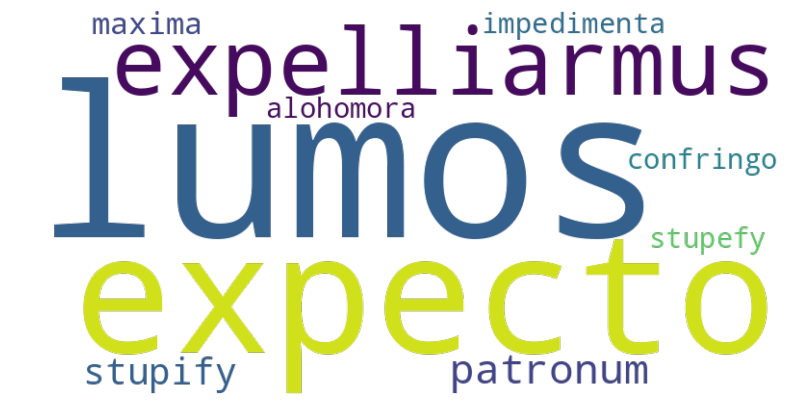

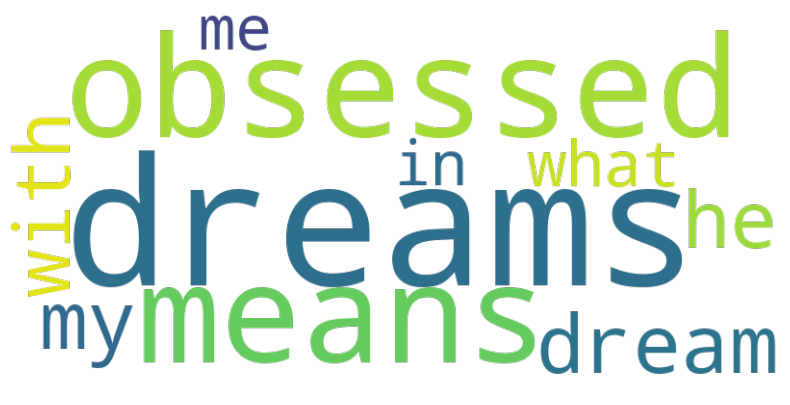

In [ ]:
for topic_id in [2, 3]:
    # topic_words = topic_model_raw.get_topic(topic_id)
    # plot_topic_wordcloud(f"BERTopic - Topic {topic_id}", topic_words)
    topic_words = topic_model_raw.get_topic(topic_id)  # returns list of (word, score)
    plot_topic_wordcloud(f"BERTopic - Topic {topic_id}", topic_words)  # uses all by default
    # plot_topic_wordcloud(f"", topic_words)  # uses all by default



In [ ]:
# import seaborn as sns
# import matplotlib.pyplot as plt

# sns.set(style="whitegrid")
# plt.figure(figsize=(12, 6))
# sns.barplot(data=nmf_dominant_topics, x='movie_title', y='count', hue='topic')
# plt.xticks(rotation=45)
# plt.title("Topic Distribution by Movie")
# plt.tight_layout()
# plt.show()


ValueError: Could not interpret value `movie_title` for `x`. An entry with this name does not appear in `data`.

<Figure size 1200x600 with 0 Axes>

In [ ]:

# models = ['LDA', 'NMF', 'BERTopic']
# scores = [lda_score, nmf_score, bertopic_score_raw]

# sns.barplot(x=models, y=scores)
# plt.title("Coherence Score Comparison")
# plt.ylabel("Coherence (c_v)")
# plt.ylim(0, 1)
# plt.show()